# Descriptive Analysis

This notebook reproduces the descriptive analyses reported in Section 4.1 of the article.

The analyses are based on the cleaned chat-level database and the final user-level database. They examine query types, query and answer length, usage profiles, temporal usage patterns, incentive-period differences, course engagement, and academic performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp

sns.set_theme(style="ticks", font_scale=1.05)


## Load the analytical databases

The chat-level database contains one row per processed question-answer pair. The user-level database contains one row per enrolled student and combines AI usage measures with academic performance and course engagement.


In [2]:
chats = pd.read_excel("databases/chat_level_final.xlsx")
users = pd.read_excel("userlevel.xlsx")

print(f"Chat-level rows: {len(chats)}")
print(f"Registered AI users: {chats['id'].nunique()}")
print(f"Students in user-level database: {len(users)}")
print(f"Unique student IDs: {users['id'].nunique()}")


Chat-level rows: 990
Registered AI users: 44
Students in user-level database: 140
Unique student IDs: 140


In [3]:
# Basic reproducibility checks
assert len(chats) == 990
assert chats["id"].nunique() == 44
assert len(users) == 140
assert users["id"].nunique() == 140
assert set(users["profile"].value_counts().index) == {"non-user", "occasional", "regular"}

print("Basic data checks passed.")
print("User profiles:")
print(users["profile"].value_counts().reindex(["non-user", "occasional", "regular"]))


Basic data checks passed.
User profiles:
profile
non-user      96
occasional    31
regular       13
Name: count, dtype: int64


## 1. Query categories

To describe how students used the tutor, each query is classified as non-relevant, homework copying, or genuine course-related (GCR). The latter category consists of relevant questions that were not classified as copied homework.


In [4]:
def categorize_query(row):
    if row["relevance"] == 0:
        return "Non-Relevant"
    elif row["homework"] == 1:
        return "Homework Copying"
    else:
        return "Genuine Course-Related"

chats["query_type"] = chats.apply(categorize_query, axis=1)

query_type_counts = chats["query_type"].value_counts().reindex(
    ["Genuine Course-Related", "Non-Relevant", "Homework Copying"]
).fillna(0).astype(int)

query_type_table = pd.DataFrame({
    "N": query_type_counts,
    "Percent": query_type_counts / len(chats) * 100
})

display(query_type_table.round(2))


,N,Percent
query_type,,
Genuine Course-Related,742,74.95
Non-Relevant,128,12.93
Homework Copying,120,12.12


### Table 1. Cross-tabulation of course relevance and homework copying

Percentages are calculated relative to all processed queries (N = 990).


In [5]:
table1_n = pd.crosstab(
    chats["homework"],
    chats["relevance"],
    margins=True
)

table1_pct = table1_n / len(chats) * 100

table1 = table1_n.astype(str) + " (" + table1_pct.round(1).astype(str) + "%)"
table1.columns = ["Non-Relevant (No)", "Relevant (Yes)", "Total"]
table1.index = ["Not copied (No)", "Copied (Yes)", "Total"]

display(table1)


,Non-Relevant (No),Relevant (Yes),Total
Not copied (No),128 (12.9%),742 (74.9%),870 (87.9%)
Copied (Yes),0 (0.0%),120 (12.1%),120 (12.1%)
Total,128 (12.9%),862 (87.1%),990 (100.0%)


## 2. Query and answer length by query category

Question and answer lengths are measured as the number of characters. We report means and standard deviations by query category and use pairwise Welch two-sample t-tests to compare the three categories.


In [6]:
category_order = [
    "Homework Copying",
    "Non-Relevant",
    "Genuine Course-Related",
    "All"
]

length_summary = []
for category in category_order:
    if category == "All":
        subset = chats
    else:
        subset = chats[chats["query_type"] == category]

    length_summary.append({
        "Category": category,
        "N": len(subset),
        "Avg Question Length": subset["question_length"].mean(),
        "SD Question Length": subset["question_length"].std(),
        "Avg Answer Length": subset["answer_length"].mean(),
        "SD Answer Length": subset["answer_length"].std()
    })

table2 = pd.DataFrame(length_summary)

table2_display = table2.copy()
table2_display["Avg Question Length"] = table2_display.apply(
    lambda x: f"{x['Avg Question Length']:.2f} ({x['SD Question Length']:.2f})", axis=1
)
table2_display["Avg Answer Length"] = table2_display.apply(
    lambda x: f"{x['Avg Answer Length']:.2f} ({x['SD Answer Length']:.2f})", axis=1
)
table2_display = table2_display[
    ["Category", "N", "Avg Question Length", "Avg Answer Length"]
]

display(table2_display)


,Category,N,Avg Question Length,Avg Answer Length
0,Homework Copying,120,435.62 (288.36),1704.50 (692.50)
1,Non-Relevant,128,31.15 (35.78),472.46 (511.74)
2,Genuine Course-Related,742,111.23 (167.99),1367.45 (538.14)
3,All,990,140.19 (209.93),1292.59 (648.19)


In [7]:
def welch_test(group_a, group_b):
    return stats.ttest_ind(group_a, group_b, equal_var=False)

comparison_pairs = [
    ("Homework Copying", "Genuine Course-Related"),
    ("Genuine Course-Related", "Non-Relevant"),
    ("Homework Copying", "Non-Relevant")
]

length_tests = []
for variable, label in [
    ("question_length", "Question Length"),
    ("answer_length", "Answer Length")
]:
    for group_a, group_b in comparison_pairs:
        a = chats.loc[chats["query_type"] == group_a, variable]
        b = chats.loc[chats["query_type"] == group_b, variable]
        result = welch_test(a, b)
        length_tests.append({
            "Outcome": label,
            "Comparison": f"{group_a} vs. {group_b}",
            "t": result.statistic,
            "p": result.pvalue
        })

length_tests = pd.DataFrame(length_tests)
display(length_tests.assign(p=length_tests["p"].map(lambda p: f"{p:.4g}")))


,Outcome,Comparison,t,p
0,Question Length,Homework Copying vs. Genuine Course-Related,11.998177,6.677e-23
1,Question Length,Genuine Course-Related vs. Non-Relevant,11.554021,9.123e-29
2,Question Length,Homework Copying vs. Non-Relevant,15.255492,4.288e-30
3,Answer Length,Homework Copying vs. Genuine Course-Related,5.088953,1.113e-06
4,Answer Length,Genuine Course-Related vs. Non-Relevant,18.132609,2.203e-42
5,Answer Length,Homework Copying vs. Non-Relevant,15.849919,3.611e-38


## 3. Student usage profiles

Students were classified into non-users, occasional users, and regular users. Regular users are those who reached at least seven distinct active days; the remaining registered users are classified as occasional.

The profile composition and query volume are summarized below. This reproduces the main student-level descriptive comparison reported in Section 4.1.


In [8]:
profile_users = (
    users["profile"]
    .value_counts()
    .reindex(["non-user", "occasional", "regular"])
    .rename("Students")
)

profile_queries = (
    chats.groupby("profile")
    .size()
    .reindex(["occasional", "regular"])
    .rename("Queries")
)

print("Students by profile:")
display(profile_users.to_frame())

print("Queries by profile:")
display(profile_queries.to_frame())

print(f"Regular-user query share: {profile_queries['regular'] / len(chats) * 100:.1f}%")


Students by profile:


,Students
profile,
non-user,96
occasional,31
regular,13


Queries by profile:


,Queries
profile,
occasional,289
regular,701


Regular-user query share: 70.8%


### Profile-level comparison of registered users

For the registered-user subgroup, average question length, average answer length, course relevance, and homework-copying rates are compared between occasional and regular users.


In [9]:
registered_users = users[users["profile"] != "non-user"].copy()

profile_variables = [
    ("avg_question_length", "Average Question Length"),
    ("avg_answer_length", "Average Answer Length"),
    ("relevance_rate", "Course Relevance"),
    ("hw_share", "Homework Copying Rate")
]

profile_comparisons = []
for variable, label in profile_variables:
    occasional = registered_users.loc[
        registered_users["profile"] == "occasional", variable
    ]
    regular = registered_users.loc[
        registered_users["profile"] == "regular", variable
    ]
    result = welch_test(occasional, regular)
    profile_comparisons.append({
        "Outcome": label,
        "Occasional Mean": occasional.mean(),
        "Regular Mean": regular.mean(),
        "t": result.statistic,
        "p": result.pvalue
    })

profile_comparisons = pd.DataFrame(profile_comparisons)
display(profile_comparisons.round(4))


,Outcome,Occasional Mean,Regular Mean,t,p
0,Average Question Length,123.9102,130.6854,-0.2303,0.8191
1,Average Answer Length,1257.9812,1293.1763,-0.3248,0.7475
2,Course Relevance,0.9007,0.8822,0.3024,0.7641
3,Homework Copying Rate,0.0943,0.1383,-0.7695,0.4474


## 4. Daily query distribution and engagement profiles

Figure 1 shows daily query volume by engagement profile. Shading identifies the non-rewarded period and the exam-panic periods defined in the data-preparation workflow.


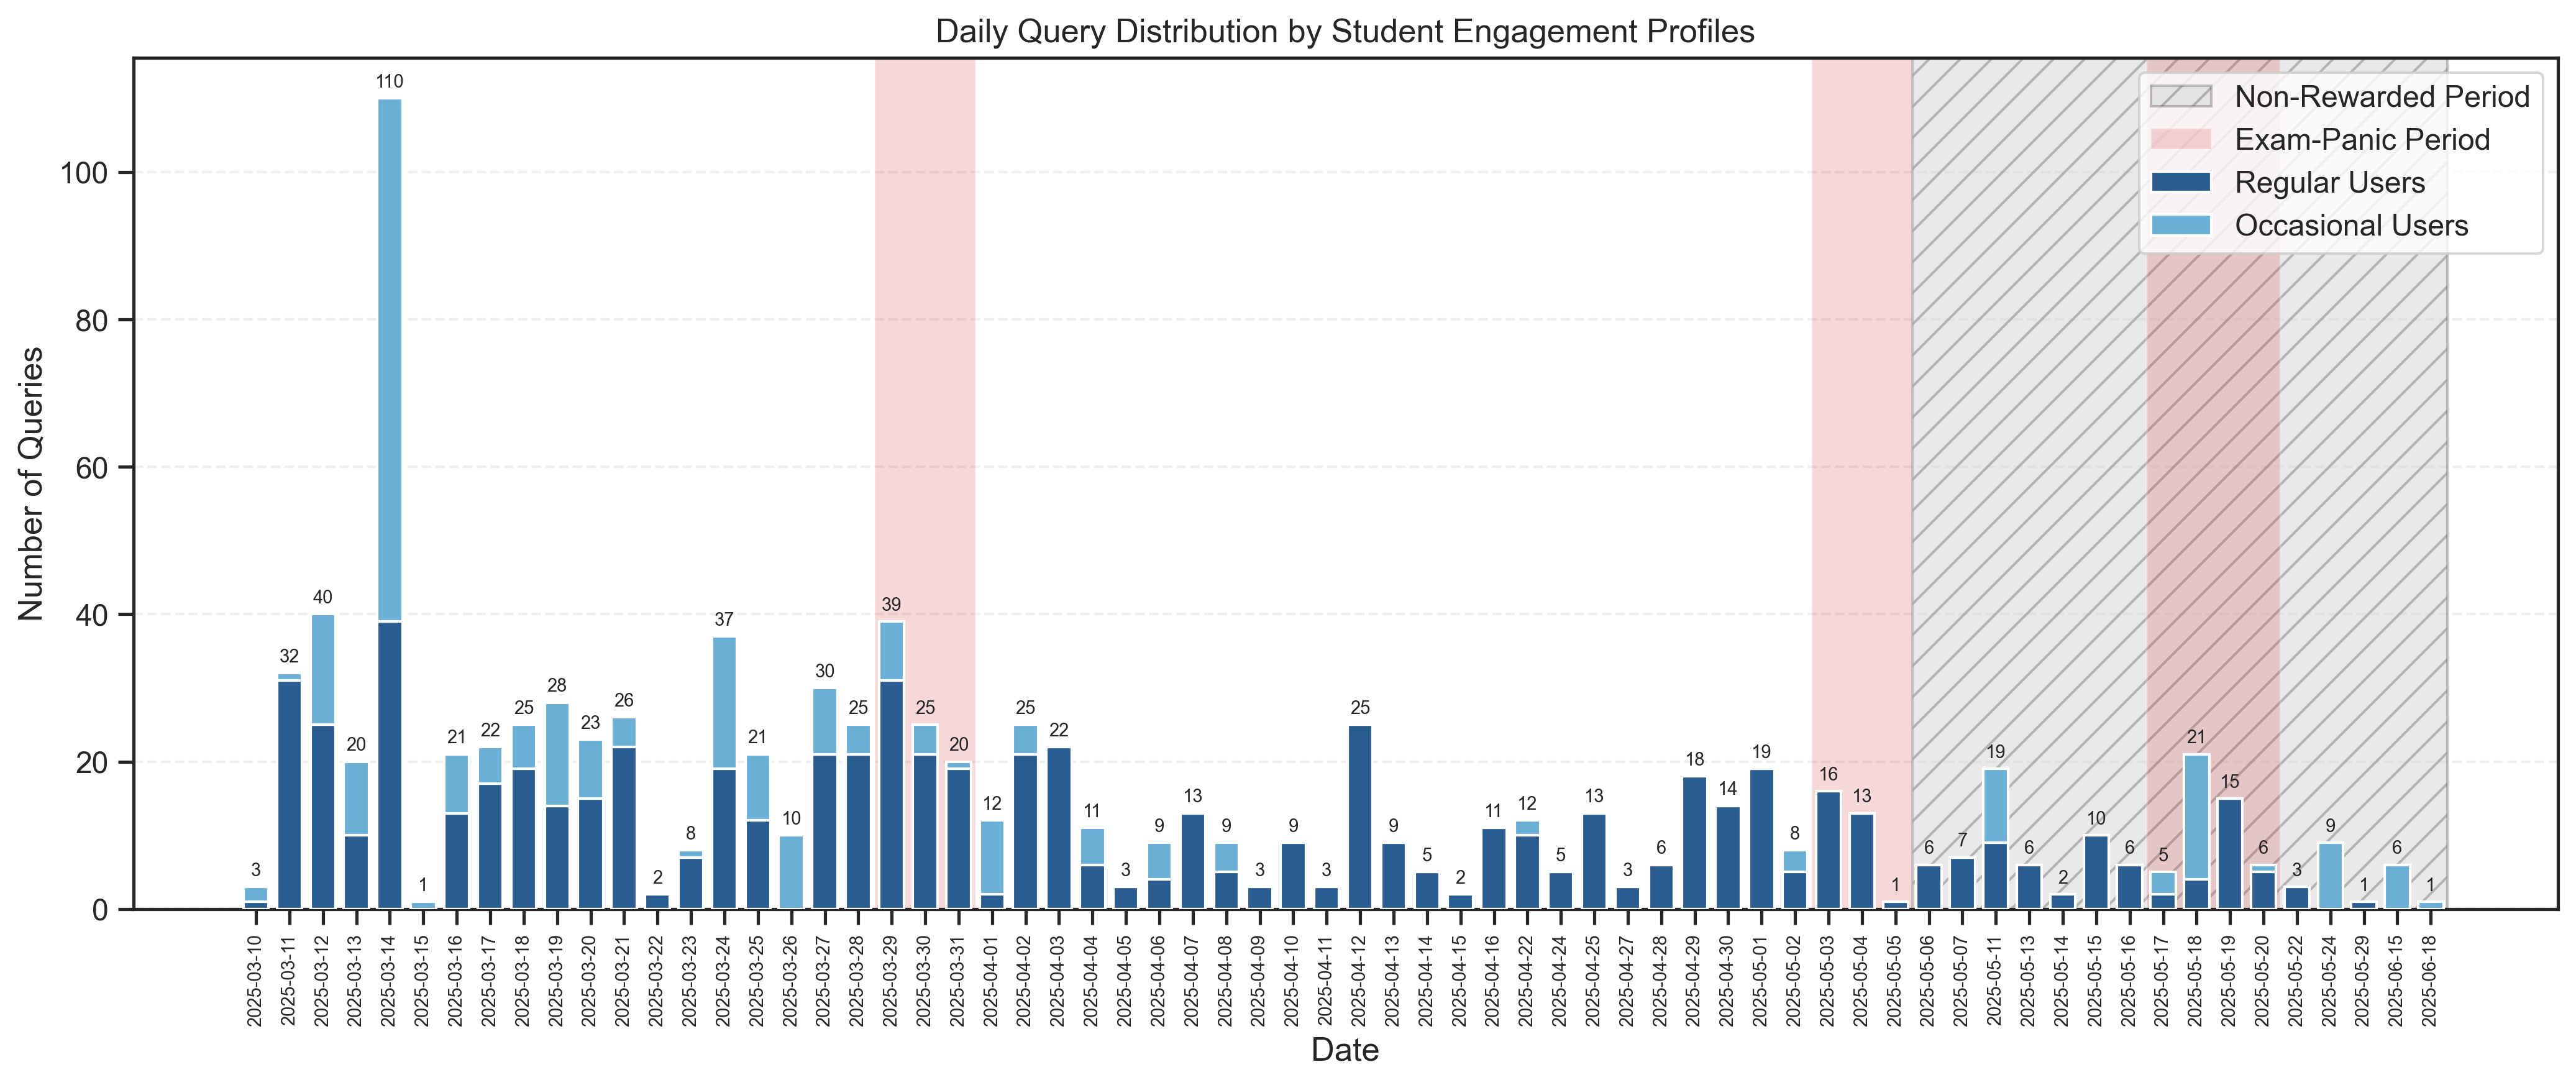

In [10]:
daily_by_profile = (
    chats.groupby(["q_date", "profile"])
    .size()
    .unstack(fill_value=0)
)

dates = daily_by_profile.index
occasional = daily_by_profile.get("occasional", pd.Series(0, index=dates)).values
regular = daily_by_profile.get("regular", pd.Series(0, index=dates)).values

total = occasional + regular

panic_ranges = [
    (pd.Timestamp("2025-03-29"), pd.Timestamp("2025-03-31"), "T2 Exam"),
    (pd.Timestamp("2025-05-03"), pd.Timestamp("2025-05-05"), "T3 Exam"),
    (pd.Timestamp("2025-05-17"), pd.Timestamp("2025-05-20"), "T4 Exam")
]

fig, ax = plt.subplots(figsize=(14, 6), dpi=300)
x = np.arange(len(dates))

ax.bar(x, regular, width=0.75, label="Regular Users", color="#2b5c8f", zorder=3)
ax.bar(
    x, occasional, bottom=regular, width=0.75,
    label="Occasional Users", color="#6baed6", zorder=3
)

for i, value in enumerate(total):
    if value > 0:
        ax.text(i, value + 1, str(value), ha="center", va="bottom", fontsize=7)

# Non-rewarded period
non_rewarded_start = pd.Timestamp("2025-05-06")
non_rewarded_idx = [i for i, d in enumerate(dates) if d >= non_rewarded_start]
if non_rewarded_idx:
    x0 = min(non_rewarded_idx) - 0.5
    x1 = len(dates) - 0.5
    ax.axvspan(
        x0, x1,
        facecolor="#d0d0d0", edgecolor="#777777",
        alpha=0.45, hatch="//", linewidth=1,
        label="Non-Rewarded Period", zorder=1
    )

# Exam-panic periods
panic_label_added = False
for start, end, exam_label in panic_ranges:
    idx = [i for i, d in enumerate(dates) if start <= d <= end]
    if idx:
        x0 = min(idx) - 0.5
        x1 = max(idx) + 0.5
        ax.axvspan(
            x0, x1,
            facecolor="#d62728", alpha=0.18,
            label="Exam-Panic Period" if not panic_label_added else "",
            zorder=2
        )
        panic_label_added = True

ax.set_title("Daily Query Distribution by Student Engagement Profiles")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Queries")
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates], rotation=90, fontsize=7)
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Early adoption and attrition checks

The article highlights the unusually high activity on 14 March and the rapid decline in use among occasional users. The following checks reproduce the underlying counts.


In [11]:
mar14 = chats[chats["q_date"] == pd.Timestamp("2025-03-14")]

print(f"Queries on 14 March: {len(mar14)}")
print(f"Users active on 14 March: {mar14['id'].nunique()}")

registration_days = chats.groupby("id")["q_date"].min()
print(f"Users whose first query was on 14 March: {(registration_days == pd.Timestamp('2025-03-14')).sum()}")
print(f"Users registered by 14 March: {(registration_days <= pd.Timestamp('2025-03-14')).sum()}")
print(f"Share of registered users registered by 14 March: {(registration_days <= pd.Timestamp('2025-03-14')).mean() * 100:.1f}%")

last_query_days = chats.groupby("id")["q_date"].max()
print(f"Users whose last query was by 31 March: {(last_query_days <= pd.Timestamp('2025-03-31')).sum()}")


Queries on 14 March: 110
Users active on 14 March: 21
Users whose first query was on 14 March: 17
Users registered by 14 March: 37
Share of registered users registered by 14 March: 84.1%
Users whose last query was by 31 March: 23


## 5. Incentivized vs. non-incentivized periods

The incentive ended on 5 May 2025 at 16:00. Questions submitted after the cutoff are classified as non-rewarded.

The table below reproduces the descriptive comparison reported in Table 3, including query volume, the composition of active registered users, average question and answer length, non-relevance, and homework copying.


In [13]:
cutoff = pd.Timestamp("2025-05-05 16:00:00")

q_time = pd.to_datetime(chats["q_time"])

if getattr(q_time.dt, "tz", None) is not None:
    q_time = q_time.dt.tz_localize(None)

chats["non_rewarded_calc"] = (q_time > cutoff).astype(int)

assert (chats["non_rewarded_calc"] == chats["non_rewarded"]).all()


# Descriptive statistics by incentive period
period_summary = (
    chats.groupby("non_rewarded")
    .agg(
        N=("id", "size"),
        avg_question_length=("question_length", "mean"),
        sd_question_length=("question_length", "std"),
        avg_answer_length=("answer_length", "mean"),
        sd_answer_length=("answer_length", "std"),
        non_relevance=("relevance", lambda x: (x == 0).mean()),
        homework_copying=("homework", "mean")
    )
    .rename(index={
        0: "Rewarded",
        1: "Non-Rewarded"
    })
)


# Number of unique occasional and regular users active in each period
profile_period = (
    chats.groupby(["non_rewarded", "profile"])["id"]
    .nunique()
    .unstack(fill_value=0)
    .rename(index={
        0: "Rewarded",
        1: "Non-Rewarded"
    })
)

period_summary["Occasional"] = profile_period["occasional"]
period_summary["Regular"] = profile_period["regular"]


# Keep the desired column order
period_summary = period_summary[[
    "N",
    "Occasional",
    "Regular",
    "avg_question_length",
    "sd_question_length",
    "avg_answer_length",
    "sd_answer_length",
    "non_relevance",
    "homework_copying"
]]


# Add total row
total_row = pd.DataFrame({
    "N": [len(chats)],
    "Occasional": [
        chats.loc[chats["profile"] == "occasional", "id"].nunique()
    ],
    "Regular": [
        chats.loc[chats["profile"] == "regular", "id"].nunique()
    ],
    "avg_question_length": [
        chats["question_length"].mean()
    ],
    "sd_question_length": [
        chats["question_length"].std()
    ],
    "avg_answer_length": [
        chats["answer_length"].mean()
    ],
    "sd_answer_length": [
        chats["answer_length"].std()
    ],
    "non_relevance": [
        (chats["relevance"] == 0).mean()
    ],
    "homework_copying": [
        chats["homework"].mean()
    ]
}, index=["Total"])

period_summary = pd.concat([
    period_summary,
    total_row
])


# Round descriptive statistics to two decimal places
period_summary[[
    "avg_question_length",
    "sd_question_length",
    "avg_answer_length",
    "sd_answer_length",
    "non_relevance",
    "homework_copying"
]] = period_summary[[
    "avg_question_length",
    "sd_question_length",
    "avg_answer_length",
    "sd_answer_length",
    "non_relevance",
    "homework_copying"
]].round(2)


display(period_summary)

,N,Occasional,Regular,avg_question_length,sd_question_length,avg_answer_length,sd_answer_length,non_relevance,homework_copying
Rewarded,866,31,13,133.55,202.89,1272.46,647.36,0.14,0.13
Non-Rewarded,124,3,10,186.59,249.82,1433.15,639.04,0.03,0.06
Total,990,31,13,140.19,209.93,1292.59,648.19,0.13,0.12


### Significance tests across incentive periods

Welch two-sample t-tests are used for question and answer length. Because relevance and homework copying are binary indicators, the same calculations are retained here as descriptive two-group mean comparisons.


In [14]:
period_tests = []

for variable, label in [
    ("question_length", "Question Length"),
    ("answer_length", "Answer Length"),
    ("relevance", "Course Relevance"),
    ("homework", "Homework Copying")
]:
    rewarded = chats.loc[chats["non_rewarded"] == 0, variable]
    non_rewarded = chats.loc[chats["non_rewarded"] == 1, variable]
    result = welch_test(non_rewarded, rewarded)
    period_tests.append({
        "Outcome": label,
        "Rewarded Mean": rewarded.mean(),
        "Non-Rewarded Mean": non_rewarded.mean(),
        "t": result.statistic,
        "p": result.pvalue
    })

display(pd.DataFrame(period_tests).round(4))


,Outcome,Rewarded Mean,Non-Rewarded Mean,t,p
0,Question Length,133.5520,186.5887,2.2598,0.0253
1,Answer Length,1272.4642,1433.1532,2.6145,0.0098
2,Course Relevance,0.8568,0.9677,5.5770,0.0000
3,Homework Copying,0.1305,0.0565,-3.1168,0.0021


## 6. Academic performance and course engagement across profiles

Table 4 reports means and standard deviations for academic performance and Kahoot-based course engagement. Test scores include zero scores, which represent observed assessment outcomes for students who did not attend an examination.


In [15]:
profile_order = ["occasional", "regular", "non-user"]

variables = [
    ("T1", "T1"),
    ("T23", "T23"),
    ("T4", "T4"),
    ("T1234", "T1234"),
    ("rel_act_pre", "Pre-Act"),
    ("rel_act_rew", "Rew-Act"),
    ("rel_act_post", "Post-Act"),
    ("rel_act", "Total-Act")
]

summary_rows = []
for profile in profile_order:
    subset = users[users["profile"] == profile]
    row = {"Profile": profile.title() if profile != "non-user" else "Non-User", "N": len(subset)}
    for variable, label in variables:
        row[label] = f"{subset[variable].mean():.3f} ({subset[variable].std():.3f})"
    summary_rows.append(row)

all_row = {"Profile": "Total", "N": len(users)}
for variable, label in variables:
    all_row[label] = f"{users[variable].mean():.3f} ({users[variable].std():.3f})"
summary_rows.append(all_row)

table4 = pd.DataFrame(summary_rows)
display(table4)


,Profile,N,T1,T23,T4,T1234,Pre-Act,Rew-Act,Post-Act,Total-Act
0,Occasional,31,0.701 (0.164),0.652 (0.187),0.677 (0.271),0.659 (0.165),0.892 (0.218),0.887 (0.131),0.887 (0.213),0.888 (0.112)
1,Regular,13,0.661 (0.234),0.681 (0.158),0.736 (0.242),0.684 (0.176),0.923 (0.146),0.894 (0.143),0.769 (0.330),0.882 (0.143)
2,Non-User,96,0.559 (0.316),0.471 (0.296),0.451 (0.352),0.479 (0.292),0.698 (0.378),0.517 (0.340),0.411 (0.441),0.542 (0.326)
3,Total,140,0.600 (0.287),0.531 (0.279),0.527 (0.345),0.538 (0.273),0.762 (0.345),0.634 (0.338),0.550 (0.442),0.651 (0.321)


## 7. Figure 2: Course engagement across semester periods

Dots represent individual Kahoot completion rates. Lines and markers represent profile means across the pre-incentive, rewarded, and post-incentive periods.


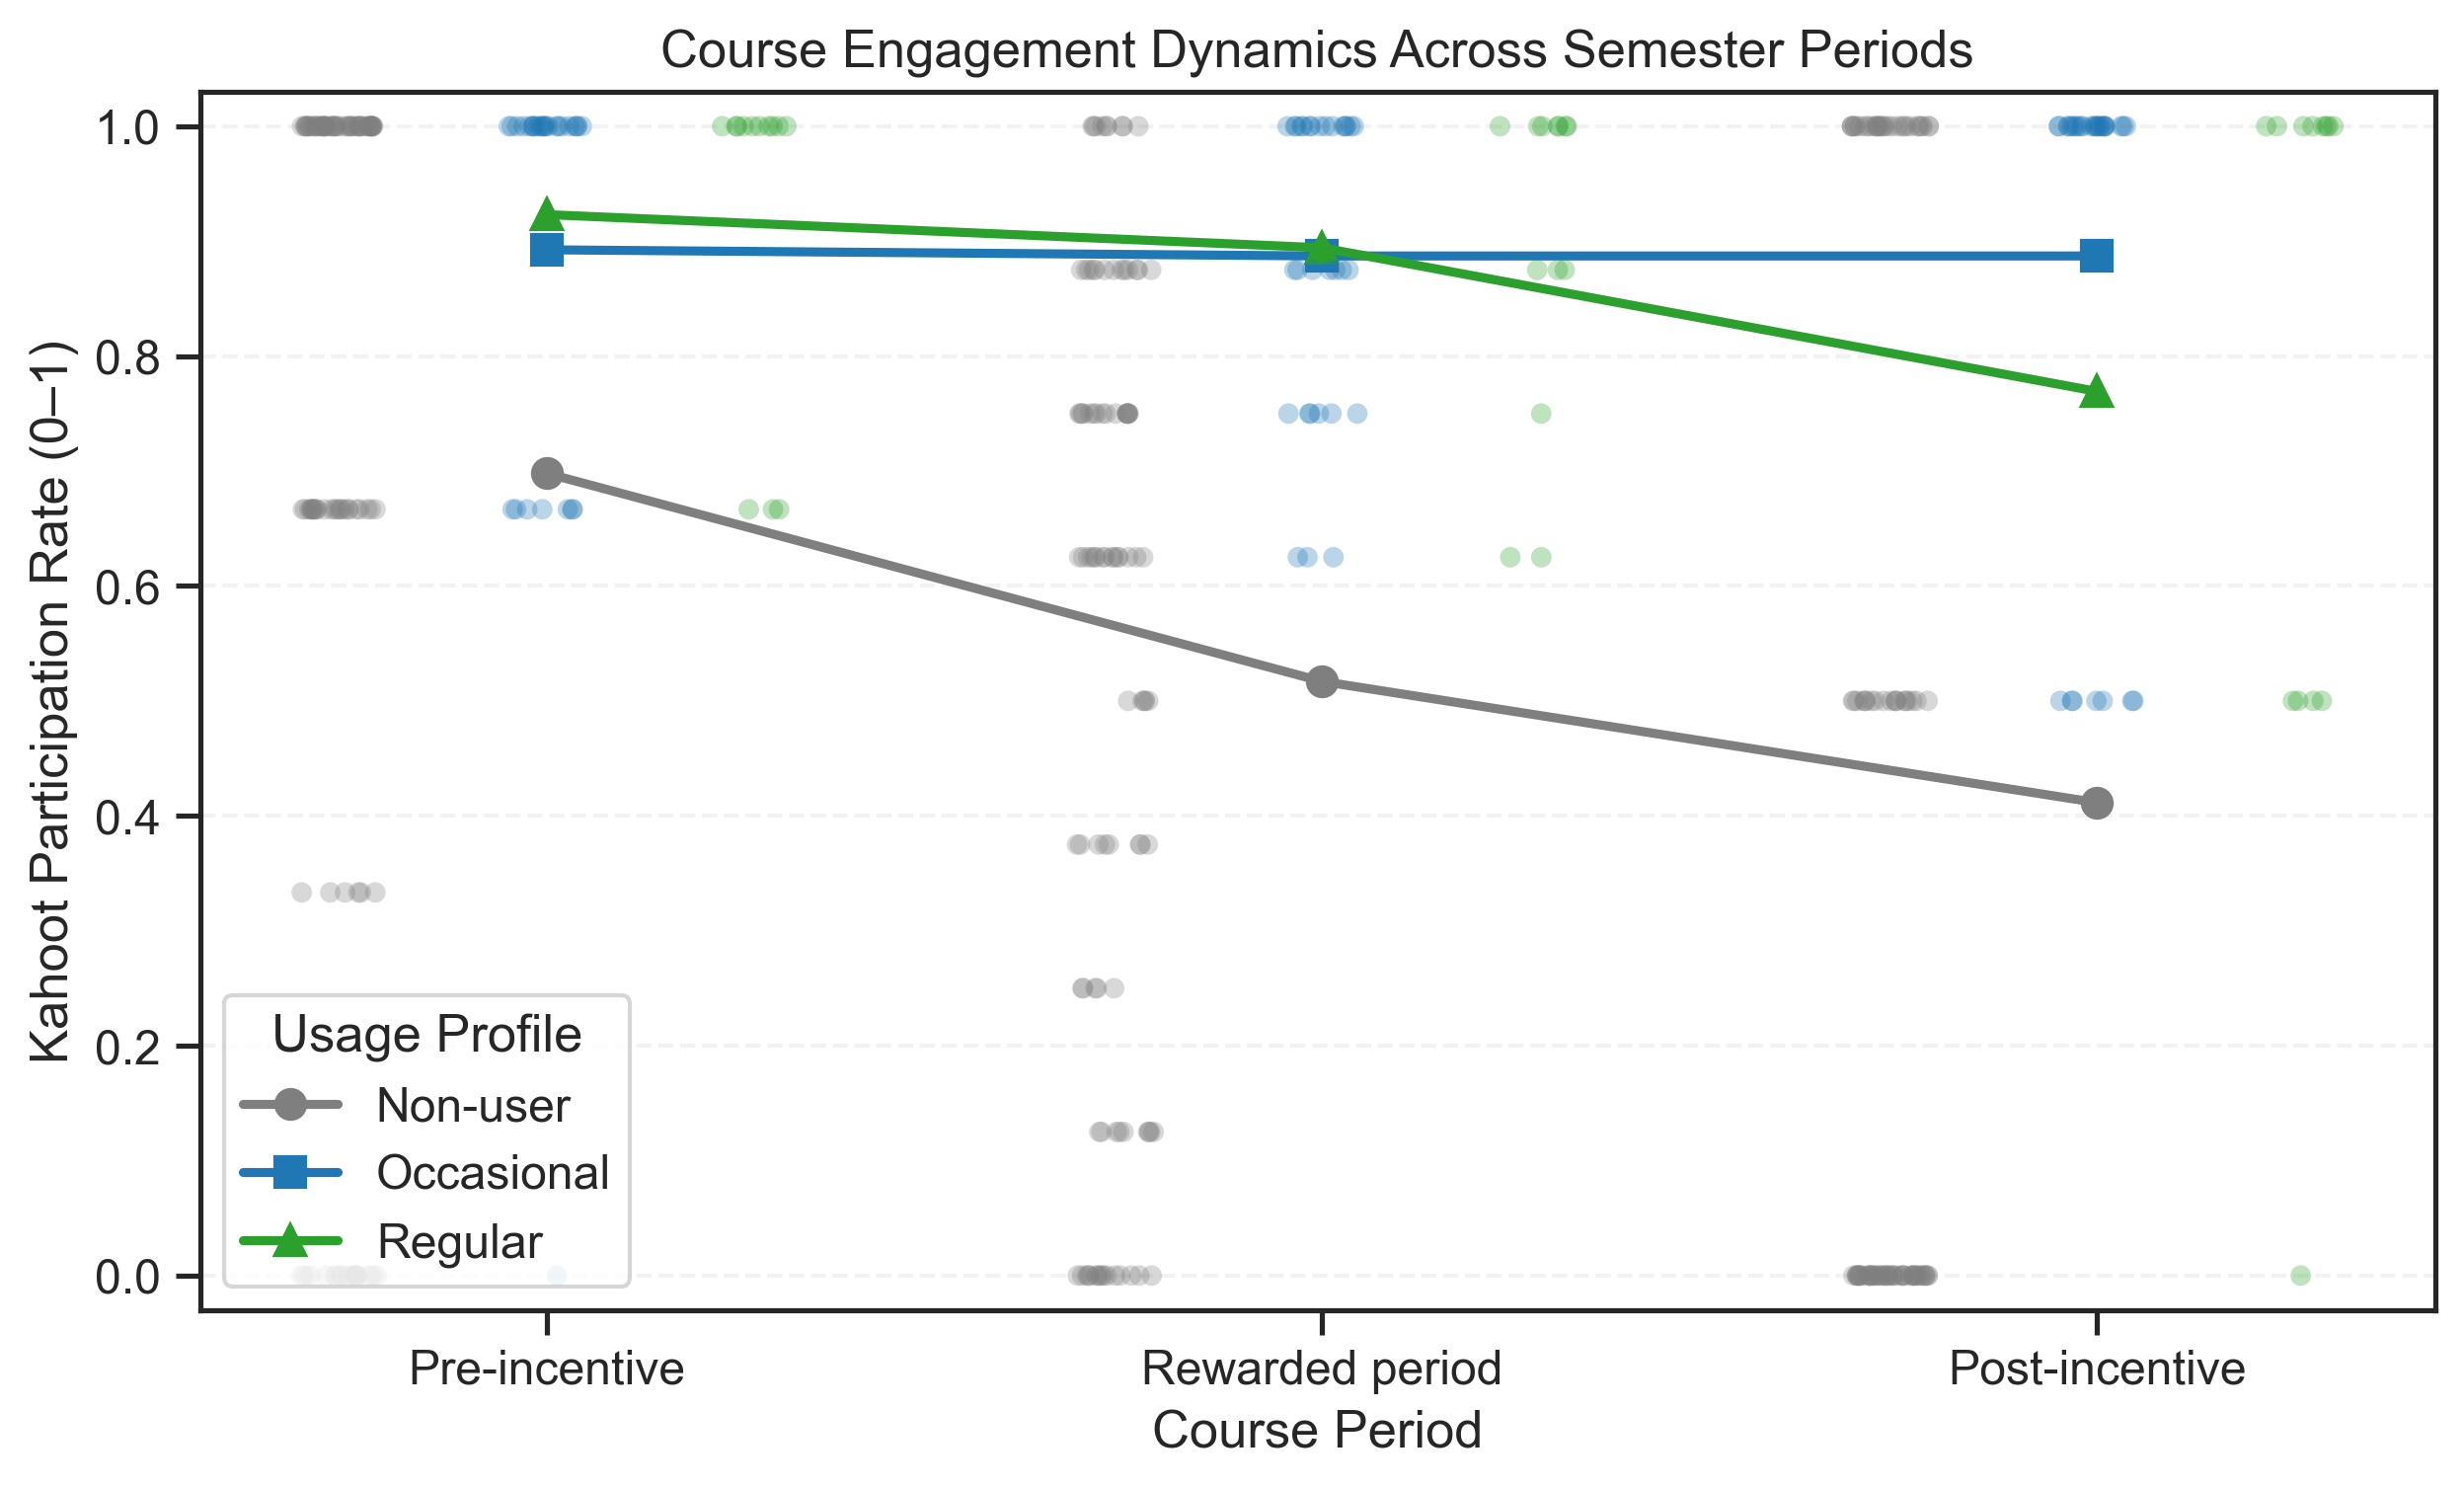

In [16]:
activity_long = users.melt(
    id_vars=["profile"],
    value_vars=["rel_act_pre", "rel_act_rew", "rel_act_post"],
    var_name="period",
    value_name="activity"
)

period_map = {
    "rel_act_pre": "Pre-incentive",
    "rel_act_rew": "Rewarded period",
    "rel_act_post": "Post-incentive"
}
profile_map = {
    "non-user": "Non-user",
    "occasional": "Occasional",
    "regular": "Regular"
}

activity_long["period_label"] = activity_long["period"].map(period_map)
activity_long["profile_label"] = activity_long["profile"].map(profile_map)

activity_means = (
    activity_long.groupby(["profile_label", "period_label"])["activity"]
    .mean()
    .unstack()
    .reindex(["Non-user", "Occasional", "Regular"])
    [["Pre-incentive", "Rewarded period", "Post-incentive"]]
)

palette = {
    "Non-user": "#7f7f7f",
    "Occasional": "#1f77b4",
    "Regular": "#2ca02c"
}
markers = {"Non-user": "o", "Occasional": "s", "Regular": "^"}

fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=300)

sns.stripplot(
    data=activity_long,
    x="period_label",
    y="activity",
    hue="profile_label",
    hue_order=["Non-user", "Occasional", "Regular"],
    palette=palette,
    alpha=0.30,
    dodge=True,
    jitter=0.15,
    size=5,
    legend=False,
    ax=ax
)

x_positions = np.arange(3)
for profile in ["Non-user", "Occasional", "Regular"]:
    ax.plot(
        x_positions,
        activity_means.loc[profile].values,
        marker=markers[profile],
        markersize=7,
        linewidth=2.2,
        label=profile,
        color=palette[profile]
    )

ax.set_title("Course Engagement Dynamics Across Semester Periods")
ax.set_xlabel("Course Period")
ax.set_ylabel("Kahoot Participation Rate (0–1)")
ax.set_ylim(-0.03, 1.03)
ax.legend(title="Usage Profile", loc="lower left")
ax.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Profile differences in course engagement

Because the subgroup distributions are heteroskedastic and non-normal, the Kruskal–Wallis test is used to test for overall differences across the three profiles. Significant omnibus tests are followed by Dunn pairwise comparisons with Holm correction.


In [17]:
def kruskal_dunn_summary(data, variable, group="profile"):
    groups = [
        data.loc[data[group] == profile, variable].dropna()
        for profile in ["non-user", "occasional", "regular"]
    ]

    kw_stat, kw_p = stats.kruskal(*groups)
    dunn = sp.posthoc_dunn(
        data[[group, variable]].dropna(),
        val_col=variable,
        group_col=group,
        p_adjust="holm"
    )

    return kw_stat, kw_p, dunn

activity_test_results = []
activity_dunn = {}

for variable, label in [
    ("rel_act_pre", "Pre-incentive Activity"),
    ("rel_act_rew", "Rewarded Activity"),
    ("rel_act_post", "Post-incentive Activity"),
    ("rel_act", "Total Relative Activity")
]:
    kw_stat, kw_p, dunn = kruskal_dunn_summary(users, variable)
    activity_test_results.append({
        "Outcome": label,
        "H": kw_stat,
        "p": kw_p
    })
    activity_dunn[variable] = dunn.round(4)

display(pd.DataFrame(activity_test_results).round(4))

for variable, dunn in activity_dunn.items():
    print(f"Dunn test — {variable} (Holm-adjusted p-values)")
    display(dunn)


,Outcome,H,p
0,Pre-incentive Activity,9.5036,0.0086
1,Rewarded Activity,41.6970,0.0000
2,Post-incentive Activity,30.2318,0.0000
3,Total Relative Activity,39.2866,0.0000


Dunn test — rel_act_pre (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.0000,0.0275,0.0773
occasional,0.0275,1.0000,0.8254
regular,0.0773,0.8254,1.0000


Dunn test — rel_act_rew (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.0000,0.0000,0.0001
occasional,0.0000,1.0000,0.9028
regular,0.0001,0.9028,1.0000


Dunn test — rel_act_post (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.000,0.0000,0.0140
occasional,0.000,1.0000,0.4078
regular,0.014,0.4078,1.0000


Dunn test — rel_act (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.0000,0.0000,0.0002
occasional,0.0000,1.0000,0.9906
regular,0.0002,0.9906,1.0000


## 9. Figure 3: Academic performance across examinations

The figure shows individual test scores and profile means for T1, T23, and T4. Zero scores are retained in the main analysis because they are part of the observed assessment outcomes; a sensitivity analysis excluding zero scores follows below.


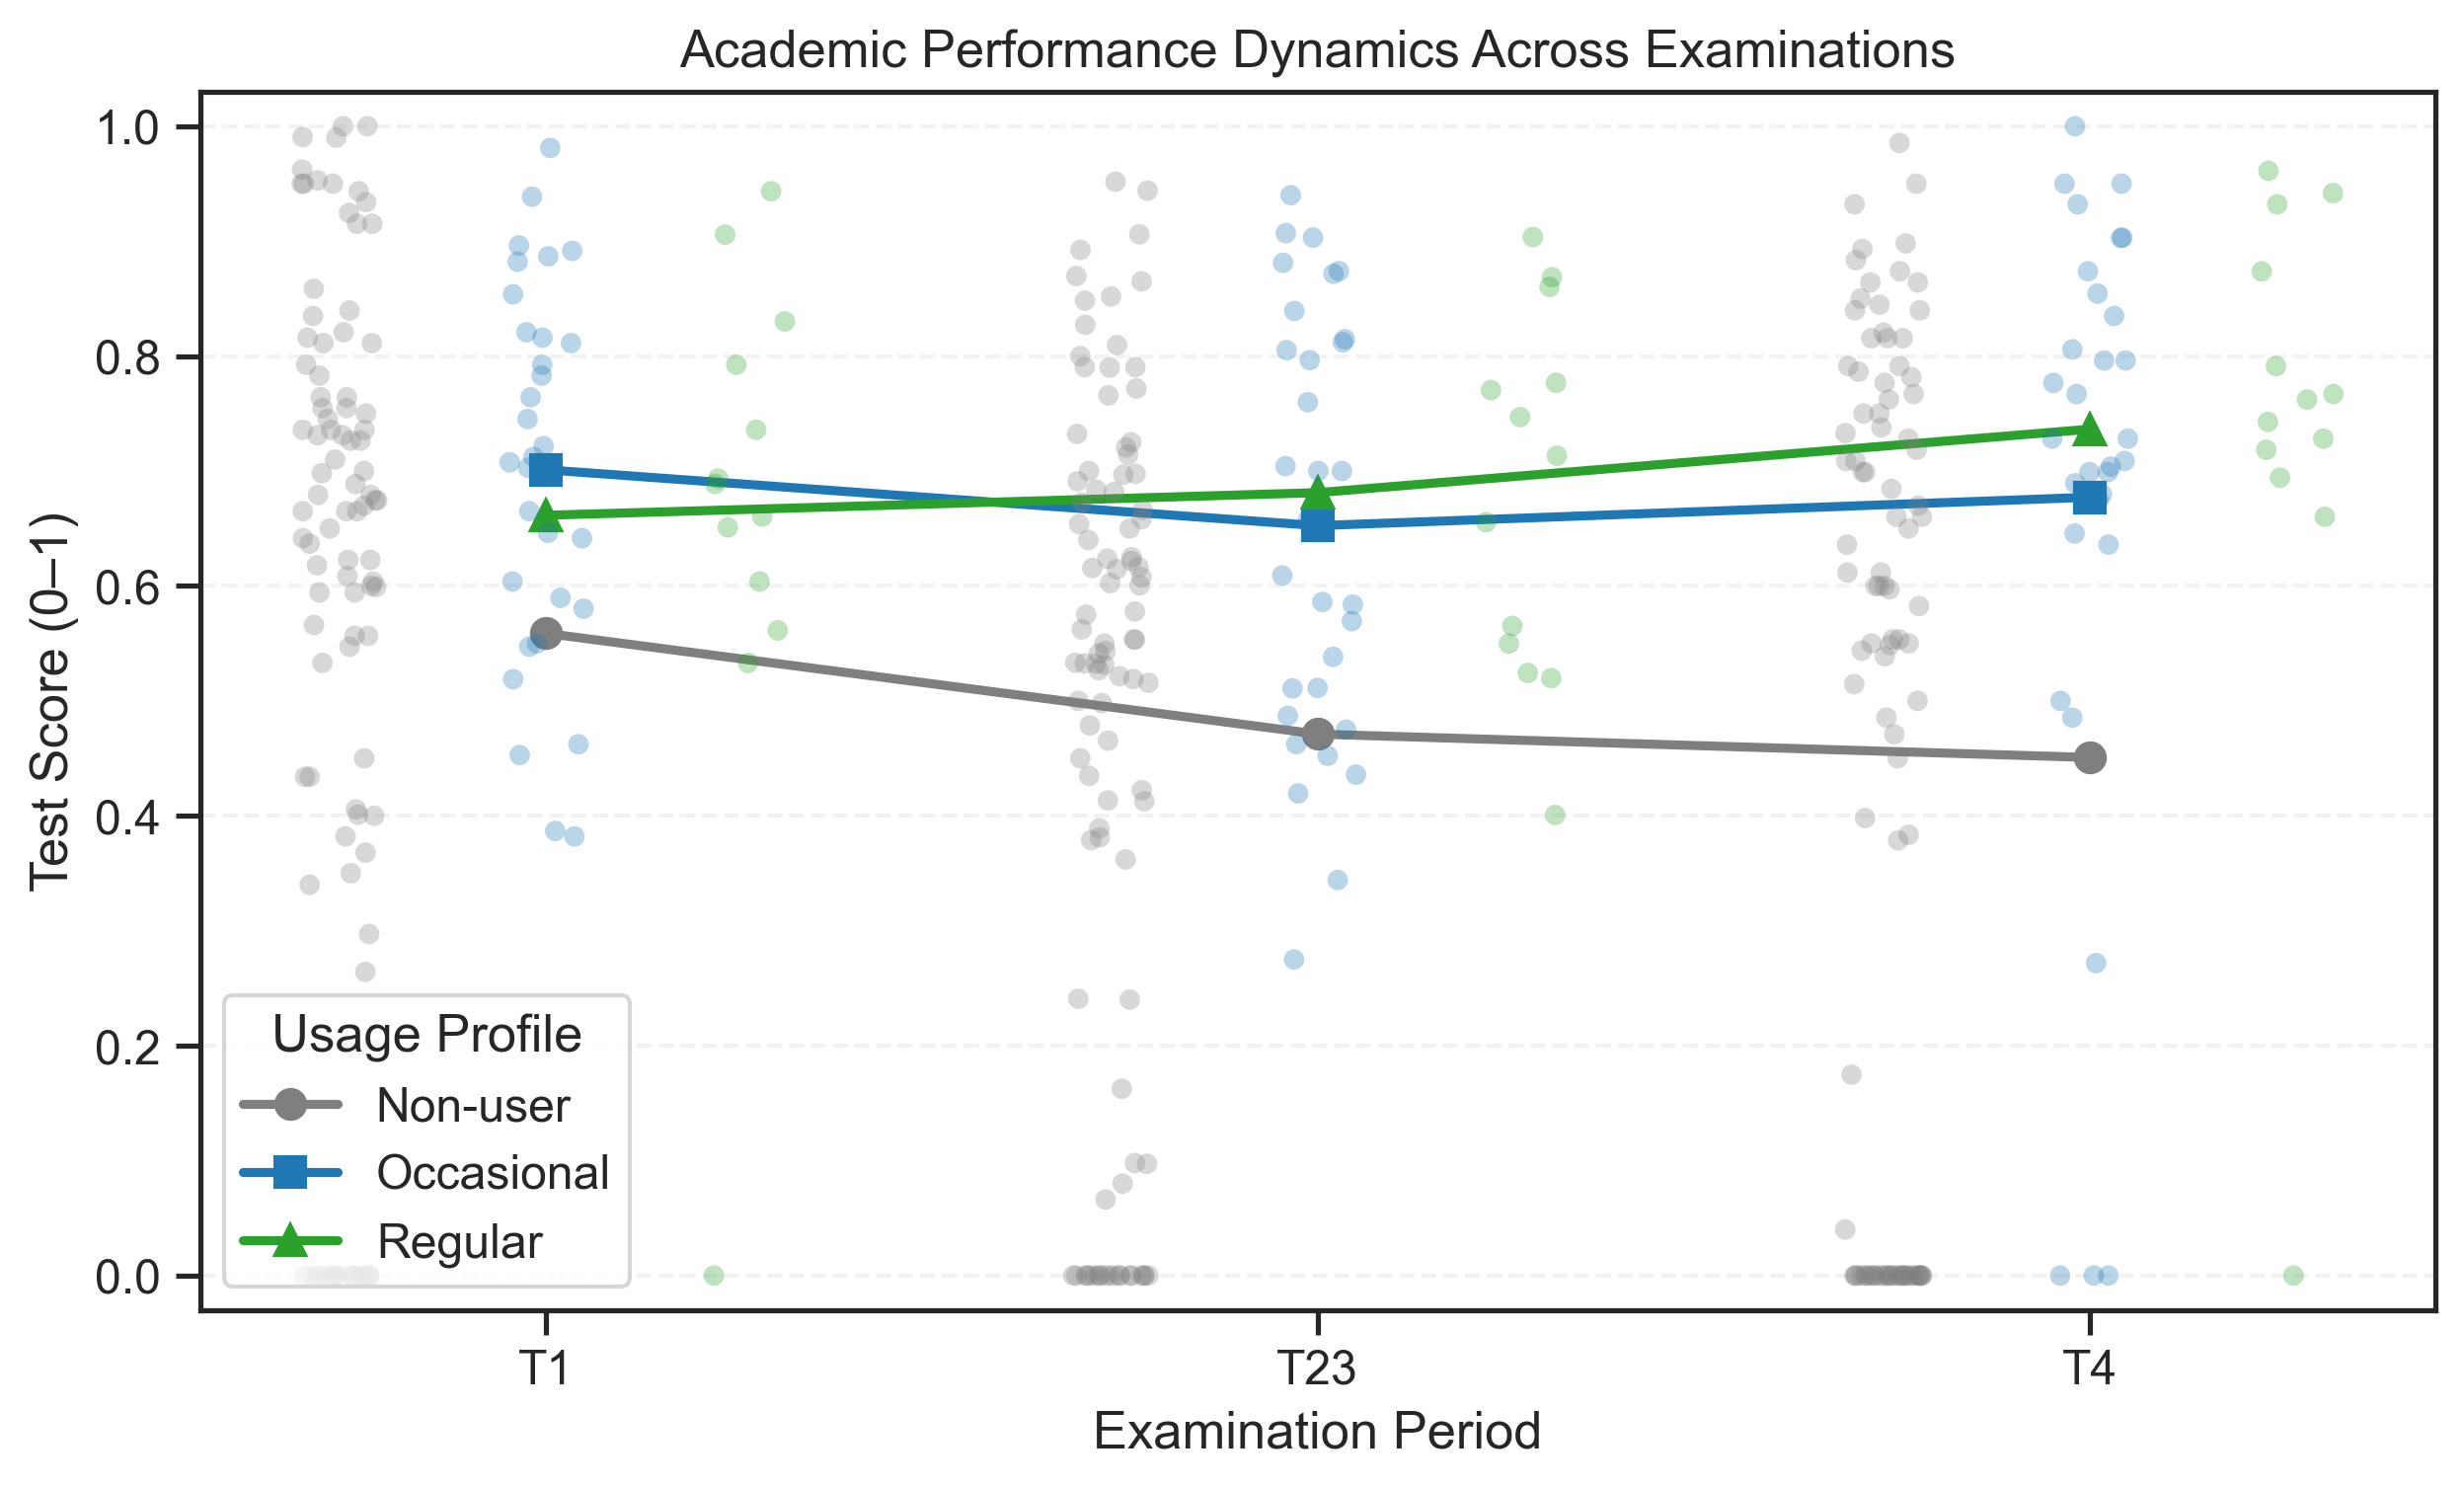

In [18]:
score_long = users.melt(
    id_vars=["profile"],
    value_vars=["T1", "T23", "T4"],
    var_name="exam",
    value_name="score"
)

score_long["exam"] = pd.Categorical(
    score_long["exam"], categories=["T1", "T23", "T4"], ordered=True
)
score_long["profile_label"] = score_long["profile"].map(profile_map)

score_means = (
    score_long.groupby(["profile_label", "exam"], observed=False)["score"]
    .mean()
    .unstack()
    .reindex(["Non-user", "Occasional", "Regular"])
    [["T1", "T23", "T4"]]
)

fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=300)

sns.stripplot(
    data=score_long,
    x="exam",
    y="score",
    hue="profile_label",
    hue_order=["Non-user", "Occasional", "Regular"],
    palette=palette,
    alpha=0.30,
    dodge=True,
    jitter=0.15,
    size=5,
    legend=False,
    ax=ax
)

for profile in ["Non-user", "Occasional", "Regular"]:
    ax.plot(
        np.arange(3),
        score_means.loc[profile].values,
        marker=markers[profile],
        markersize=7,
        linewidth=2.2,
        label=profile,
        color=palette[profile]
    )

ax.set_title("Academic Performance Dynamics Across Examinations")
ax.set_xlabel("Examination Period")
ax.set_ylabel("Test Score (0–1)")
ax.set_ylim(-0.03, 1.03)
ax.legend(title="Usage Profile", loc="lower left")
ax.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


## 10. Profile differences in academic performance

Kruskal–Wallis tests assess whether test-score distributions differ across the three usage profiles. Dunn pairwise comparisons use Holm correction.


In [19]:
score_test_results = []
score_dunn = {}

for variable, label in [
    ("T1", "T1 Score"),
    ("T23", "T23 Score"),
    ("T4", "T4 Score"),
    ("T1234", "Overall Exam Performance")
]:
    kw_stat, kw_p, dunn = kruskal_dunn_summary(users, variable)
    score_test_results.append({
        "Outcome": label,
        "H": kw_stat,
        "p": kw_p
    })
    score_dunn[variable] = dunn.round(4)

display(pd.DataFrame(score_test_results).round(4))

for variable, dunn in score_dunn.items():
    print(f"Dunn test — {variable} (Holm-adjusted p-values)")
    display(dunn)


,Outcome,H,p
0,T1 Score,3.4854,0.1750
1,T23 Score,11.0397,0.0040
2,T4 Score,16.4608,0.0003
3,Overall Exam Performance,10.6534,0.0049


Dunn test — T1 (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.0000,0.2260,0.7763
occasional,0.2260,1.0000,0.7763
regular,0.7763,0.7763,1.0000


Dunn test — T23 (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.0000,0.0196,0.0381
occasional,0.0196,1.0000,0.6916
regular,0.0381,0.6916,1.0000


Dunn test — T4 (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.0000,0.0041,0.0054
occasional,0.0041,1.0000,0.4980
regular,0.0054,0.4980,1.0000


Dunn test — T1234 (Holm-adjusted p-values)


,non-user,occasional,regular
non-user,1.000,0.0350,0.0350
occasional,0.035,1.0000,0.5258
regular,0.035,0.5258,1.0000


## 11. Sensitivity analysis excluding zero test scores

A substantial number of zero test scores are present, predominantly among non-users. These may reflect examination non-attendance rather than actual performance at the bottom of the proficiency scale. As a robustness check, zero scores are treated as missing and the profile comparisons are repeated.


In [20]:
users_nozero = users.copy()

for col in ["T1", "T23", "T4"]:
    users_nozero[col] = users_nozero[col].replace(0, np.nan)

users_nozero["T1234_clean"] = users_nozero[["T1", "T23", "T4"]].mean(axis=1)

clean_test_results = []
clean_dunn = {}

for variable, label in [
    ("T1", "T1 Score, zero excluded"),
    ("T23", "T23 Score, zero excluded"),
    ("T4", "T4 Score, zero excluded"),
    ("T1234_clean", "Overall Exam Performance, zero excluded")
]:
    kw_stat, kw_p, dunn = kruskal_dunn_summary(users_nozero, variable)
    clean_test_results.append({
        "Outcome": label,
        "H": kw_stat,
        "p": kw_p
    })
    clean_dunn[variable] = dunn.round(4)

display(pd.DataFrame(clean_test_results).round(4))

print("Recalculated profile means excluding zero scores:")
clean_means = (
    users_nozero.groupby("profile")[["T1", "T23", "T4", "T1234_clean"]]
    .mean()
    .reindex(["occasional", "regular", "non-user"])
)
display(clean_means.round(3))


,Outcome,H,p
0,"T1 Score, zero excluded",0.2030,0.9035
1,"T23 Score, zero excluded",3.1090,0.2113
2,"T4 Score, zero excluded",6.7696,0.0339
3,"Overall Exam Performance, zero excluded",5.7734,0.0558


Recalculated profile means excluding zero scores:


,T1,T23,T4,T1234_clean
profile,,,,
occasional,0.701,0.652,0.750,0.697
regular,0.717,0.681,0.798,0.724
non-user,0.679,0.587,0.676,0.621


### Appendix Table A.1 — Pearson Correlation Matrix

Pearson correlations were calculated between question length, answer length, homework copying, and course relevance. Significance levels are indicated by asterisks.

In [21]:
from scipy.stats import pearsonr

vars_to_corr = [
    "question_length",
    "answer_length",
    "homework",
    "relevance"
]

n_vars = len(vars_to_corr)

corr_matrix = pd.DataFrame(
    index=vars_to_corr,
    columns=vars_to_corr,
    dtype=float
)

p_matrix = pd.DataFrame(
    index=vars_to_corr,
    columns=vars_to_corr,
    dtype=float
)

for i in range(n_vars):
    for j in range(n_vars):
        var1 = vars_to_corr[i]
        var2 = vars_to_corr[j]

        r, p_val = pearsonr(chats[var1], chats[var2])

        corr_matrix.loc[var1, var2] = r
        p_matrix.loc[var1, var2] = p_val


# Format the correlation matrix
formatted_table = pd.DataFrame(
    index=vars_to_corr,
    columns=vars_to_corr
)

for i in range(n_vars):
    for j in range(n_vars):

        if i < j:
            # Leave the upper triangle empty
            formatted_table.iloc[i, j] = ""

        elif i == j:
            # Diagonal
            formatted_table.iloc[i, j] = "1.000"

        else:
            # Lower triangle: correlation coefficient + significance stars
            r_val = corr_matrix.iloc[i, j]
            p_val = p_matrix.iloc[i, j]

            stars = ""

            if p_val < 0.001:
                stars = "***"
            elif p_val < 0.01:
                stars = "**"
            elif p_val < 0.05:
                stars = "*"

            formatted_table.iloc[i, j] = f"{r_val:.3f}{stars}"


print("=== Pearson Correlation Matrix ===")
display(formatted_table)

print("\n=== P-values (for verification) ===")
display(p_matrix.round(5))

=== Pearson Correlation Matrix ===


,question_length,answer_length,homework,relevance
question_length,1.000,,,
answer_length,0.438***,1.000,,
homework,0.523***,0.236***,1.000,
relevance,0.200***,0.488***,0.143***,1.000



=== P-values (for verification) ===


,question_length,answer_length,homework,relevance
question_length,0.0,0.0,0.00000,0.00000
answer_length,0.0,0.0,0.00000,0.00000
homework,0.0,0.0,0.00000,0.00001
relevance,0.0,0.0,0.00001,0.00000


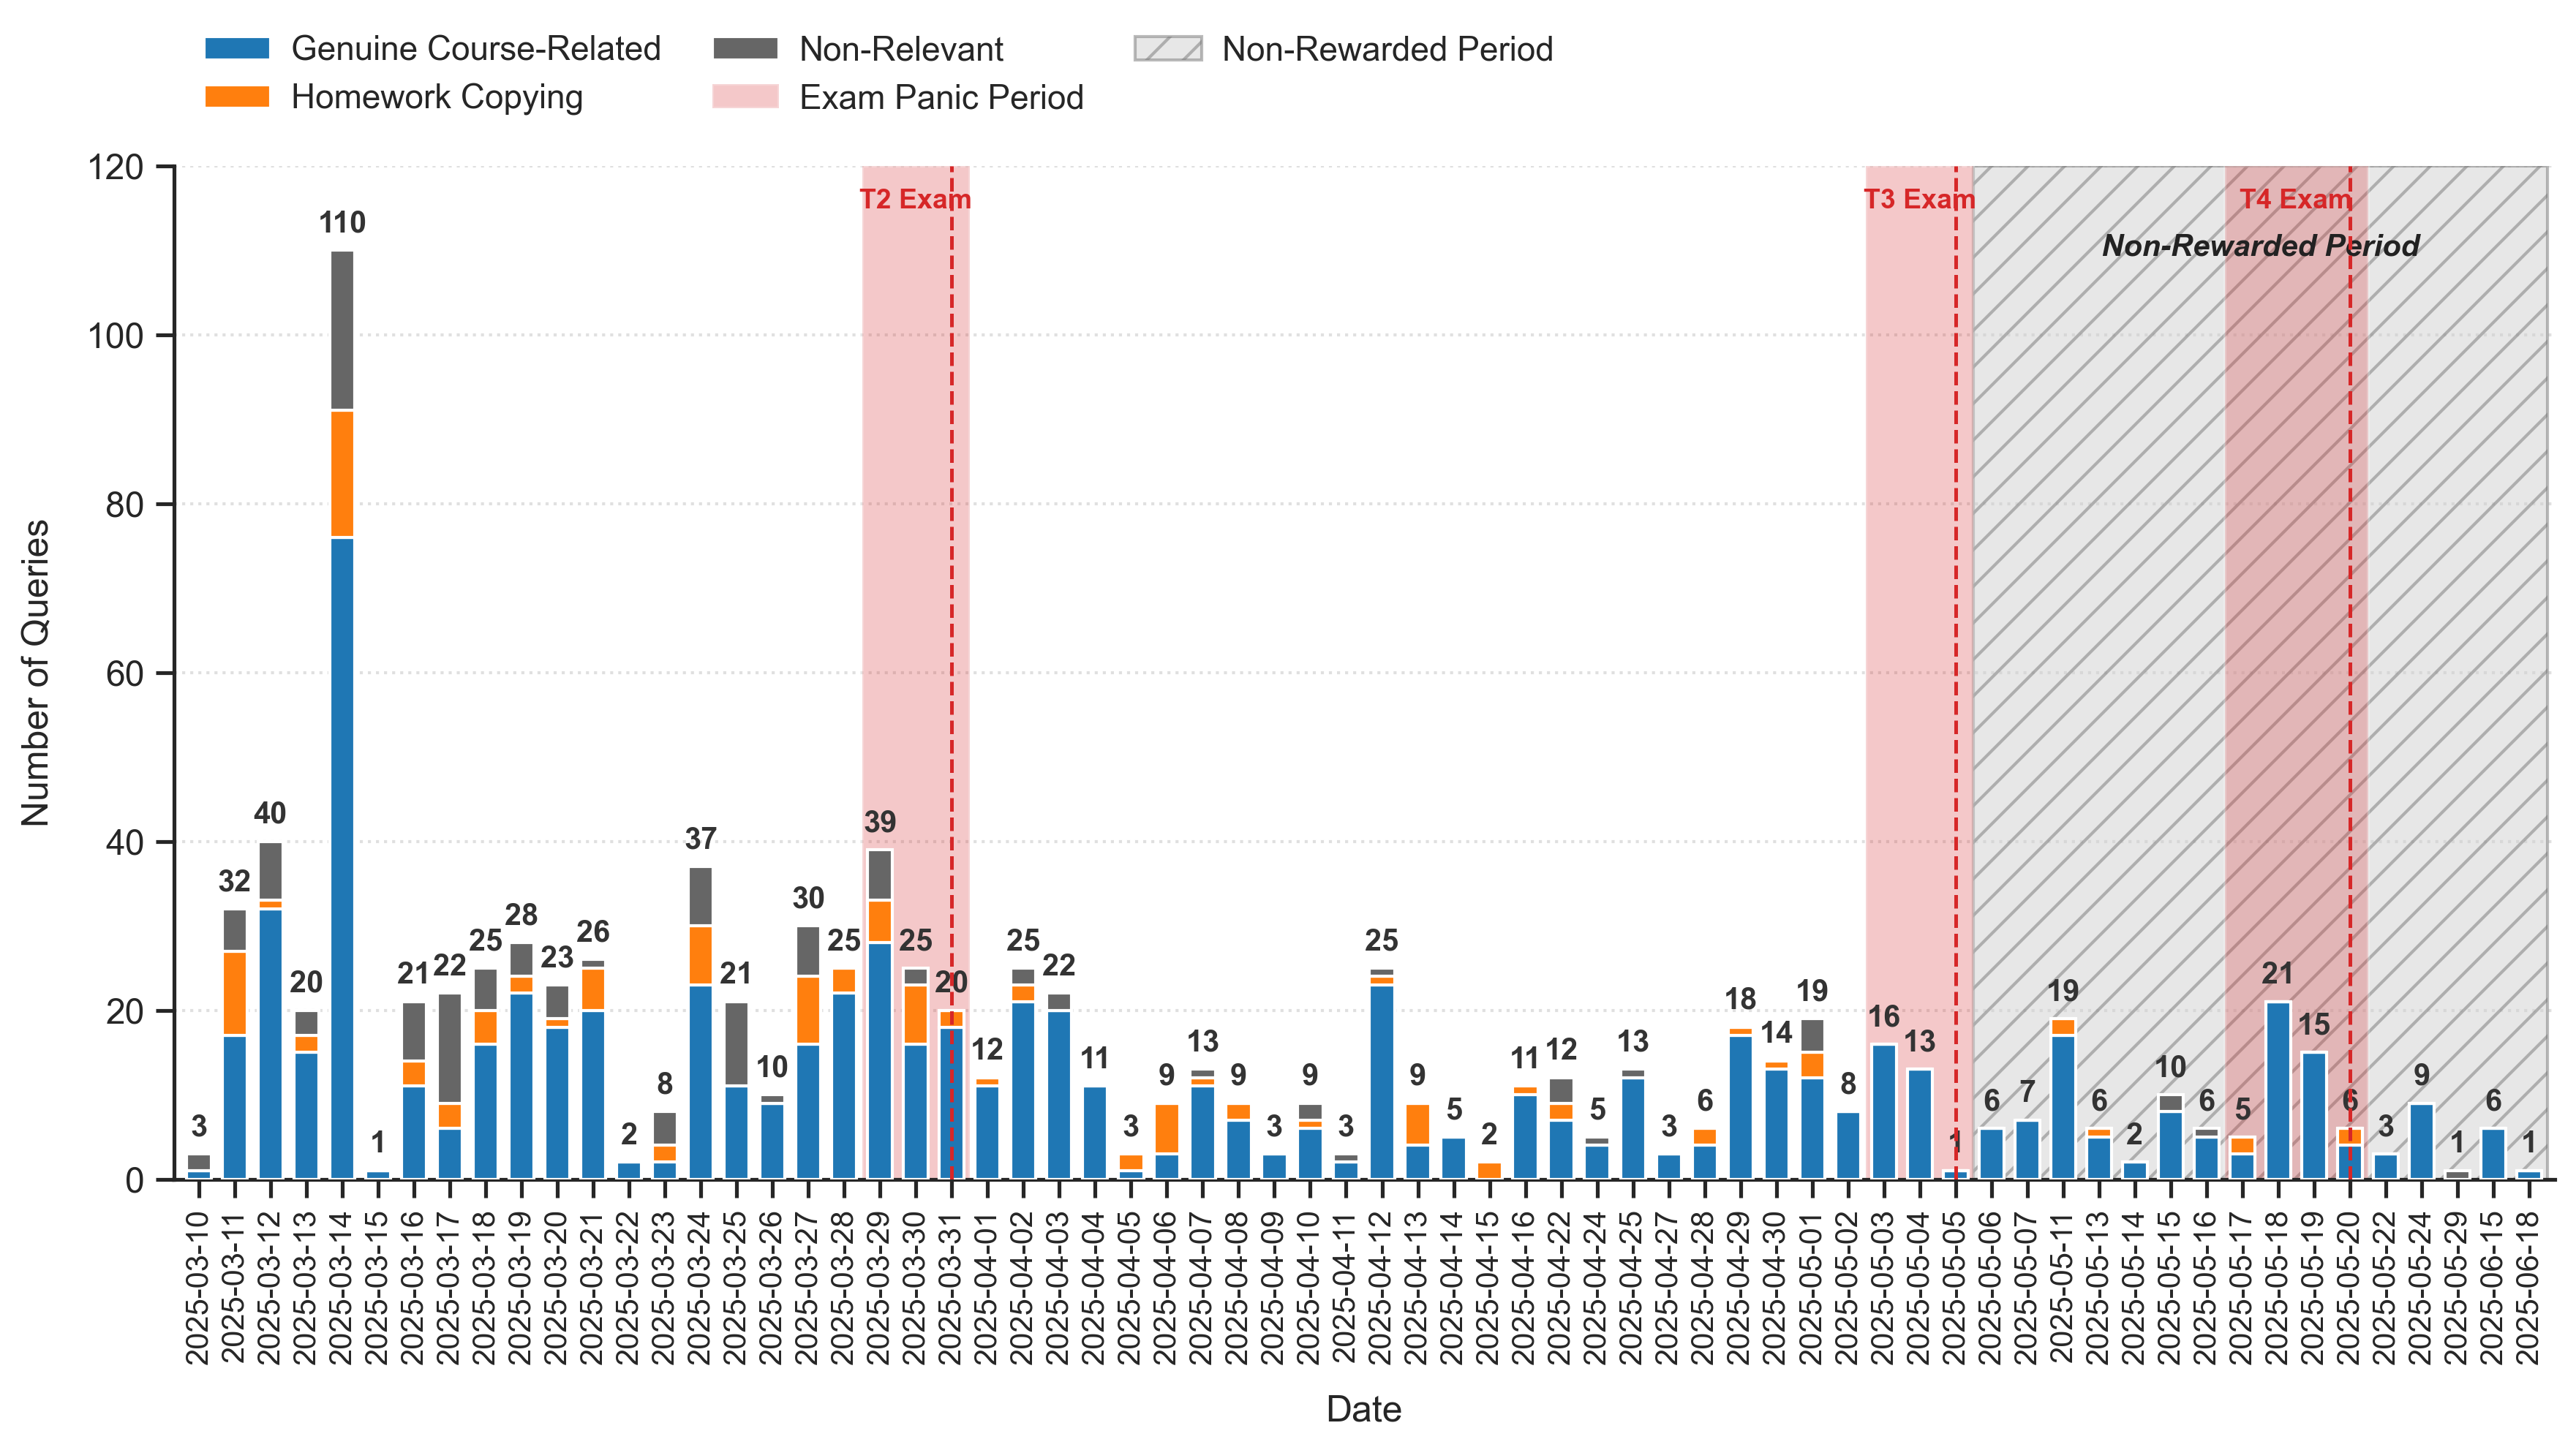

In [22]:
daily_by_type = chats.groupby(['q_date', 'query_type']).size().unstack(fill_value=0)
dates_list = list(daily_by_type.index)

gcr_vals = daily_by_type.get(
    'Genuine Course-Related',
    pd.Series(0, index=dates_list)
).values

hw_vals = daily_by_type.get(
    'Homework Copying',
    pd.Series(0, index=dates_list)
).values

irrel_vals = daily_by_type.get(
    'Non-Relevant',
    pd.Series(0, index=dates_list)
).values

total_vals = gcr_vals + hw_vals + irrel_vals


panic_ranges = [
    (
        pd.Timestamp('2025-03-29'),
        pd.Timestamp('2025-03-31'),
        'T2 Exam',
        pd.Timestamp('2025-03-31')
    ),
    (
        pd.Timestamp('2025-05-03'),
        pd.Timestamp('2025-05-05'),
        'T3 Exam',
        pd.Timestamp('2025-05-05')
    ),
    (
        pd.Timestamp('2025-05-17'),
        pd.Timestamp('2025-05-20'),
        'T4 Exam',
        pd.Timestamp('2025-05-20')
    ),
]


fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

c_gcr = '#1f77b4'
c_hw = '#ff7f0e'
c_irrel = '#666666'
c_panic = '#d62728'


non_rewarded_start = pd.Timestamp('2025-05-06')

nr_indices = [
    i for i, d in enumerate(dates_list)
    if d >= non_rewarded_start
]

if nr_indices:
    x_nr_start = min(nr_indices) - 0.5
    x_nr_end = len(dates_list) - 0.5

    nr_patch = ax.axvspan(
        x_nr_start,
        x_nr_end,
        facecolor='#d0d0d0',
        edgecolor='#777777',
        alpha=0.5,
        hatch='//',
        linewidth=1.0,
        zorder=1
    )

    ax.text(
        (x_nr_start + x_nr_end) / 2,
        112,
        'Non-Rewarded Period',
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold',
        fontstyle='italic',
        color='#222222',
        zorder=4
    )



for start_d, end_d, label_text, exam_d in panic_ranges:

    matching_indices = [
        i for i, d in enumerate(dates_list)
        if start_d <= d <= end_d
    ]

    if matching_indices:

        x_start = min(matching_indices) - 0.5
        x_end = max(matching_indices) + 0.5

        ax.axvspan(
            x_start,
            x_end,
            facecolor=c_panic,
            alpha=0.25,
            zorder=1
        )

        exam_idx = [
            i for i, d in enumerate(dates_list)
            if d == exam_d
        ]

        if exam_idx:

            ax.axvline(
                exam_idx[0],
                color=c_panic,
                linestyle='--',
                linewidth=1.2,
                zorder=4
            )

            ax.text(
                (x_start + x_end) / 2,
                max(total_vals) * 1.04,
                label_text,
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color=c_panic,
                zorder=5
            )


b1 = ax.bar(
    range(len(dates_list)),
    gcr_vals,
    color=c_gcr,
    width=0.7,
    label='Genuine Course-Related',
    zorder=3
)

b2 = ax.bar(
    range(len(dates_list)),
    hw_vals,
    bottom=gcr_vals,
    color=c_hw,
    width=0.7,
    label='Homework Copying',
    zorder=3
)

b3 = ax.bar(
    range(len(dates_list)),
    irrel_vals,
    bottom=gcr_vals + hw_vals,
    color=c_irrel,
    width=0.7,
    label='Non-Relevant',
    zorder=3
)


for i, total in enumerate(total_vals):

    if total > 0:
        ax.text(
            i,
            total + 1.5,
            str(total),
            ha='center',
            va='bottom',
            fontsize=10,
            color='#333333',
            fontweight='bold'
        )


ax.set_xlabel(
    'Date',
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    'Number of Queries',
    fontsize=12,
    labelpad=10
)

ax.set_ylim(0, 120)

ax.set_xlim(
    -0.7,
    len(dates_list) - 0.3
)

formatted_dates = [
    d.strftime('%Y-%m-%d')
    for d in dates_list
]

ax.set_xticks(range(len(dates_list)))

ax.set_xticklabels(
    formatted_dates,
    rotation=90,
    fontsize=10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle=':',
    alpha=0.6,
    zorder=2
)


import matplotlib.patches as mpatches

panic_patch_leg = mpatches.Patch(
    facecolor=c_panic,
    alpha=0.25,
    label="Exam Panic Period"
)

nr_patch_leg = mpatches.Patch(
    facecolor="#d0d0d0",
    edgecolor="#777777",
    hatch="//",
    alpha=0.5,
    label="Non-Rewarded Period"
)

handles = [
    b1,
    b2,
    b3,
    panic_patch_leg,
    nr_patch_leg
]

ax.legend(
    handles=handles,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02),
    ncol=3,
    frameon=False,
    fontsize=11,
    handletextpad=0.6,
    columnspacing=1.5
)


plt.show()